In [1]:
from __future__ import annotations

import sys
from pathlib import Path
from tqdm import trange
import numpy as np
ROOT = Path.cwd().resolve()
while ROOT.name and not (ROOT / 'hidden_sector_DM').is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from hidden_sector_DM.HiddenSectorDM import VectorPortal, BaryonPortal, HiggsPortal 

from GCE.likelihood import cascade_template, gls_fit, measurement   # noqa: E402
from GCE.pythia_runner import DEFAULT_SEED                     # noqa: E402
from scipy.ndimage import shift as ndimage_shift
from GCE.halo import HALO_2112, RHO_LOCAL_PRIOR
import numpy as np
import matplotlib as mpl
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.path import Path as MplPath
from matplotlib.tri import Triangulation, LinearTriInterpolator
from scipy.ndimage import gaussian_filter, gaussian_filter1d
import time
from hidden_sector_DM.HiddenSectorDM import Cosmology, BoltzmannSolver, s0_cosmo, rhoc
from GCE.spectrum import GEVM2_TO_CM3S
from scipy.optimize import brentq
from scipy.interpolate import griddata
plt.style.use(ROOT / 'notebooks' / 'mine.mplstyle')
plt.rcParams['axes.axisbelow'] = False

In [2]:
# ---- configuration -------------------------------------------------------
MX_LIM = (15.0, 100.0)   # GeV
MY_LIM = (5.0, 100.0)    # GeV, capped from above by mX
N_POINTS = 16384
N_COLS = 124
DECIMALS = 2

def triangle_grid(n_points: int = N_POINTS, n_cols: int = N_COLS,
                  mx_lim=MX_LIM, my_lim=MY_LIM, decimals: int = DECIMALS):
    """The grid as a (2, `n_points`) array of (mX, mY) in GeV."""
    u = np.linspace(*np.log10(mx_lim), n_cols)          # log10 mX per column
    v_lo = np.log10(my_lim[0])
    v_hi = np.minimum(u, np.log10(my_lim[1]))           # the mY <= mX edge
    height = v_hi - v_lo
    if not (height > 0).all():
        raise ValueError("some column has no room in mY; check the limits")

    # Points per column, proportional to column height.  Largest-remainder
    # apportionment, so the total is exactly `n_points`.
    raw = height / height.sum() * n_points
    n = np.floor(raw).astype(int)
    short = n_points - n.sum()
    if short:
        n[np.argsort(n - raw)[:short]] += 1
    if n.min() < 2:
        raise ValueError(f"column of {n.min()} point(s): lower N_COLS")

    mX = np.repeat(10.0 ** u, n)
    mY = np.concatenate([10.0 ** np.linspace(v_lo, hi, k)
                         for hi, k in zip(v_hi, n)])
    return np.round(np.vstack([mX, mY]), decimals)

STRIDE = 1

def thin(grid, stride: int):
    """Every `stride`-th point in both directions, trapezoid edges kept."""
    if stride == 1:
        return grid
    mX = grid[0]
    starts = np.flatnonzero(np.r_[True, np.diff(mX) != 0.0])   # column starts
    ends = np.r_[starts[1:], mX.size]
    cols = np.unique(np.r_[np.arange(0, starts.size, stride), starts.size - 1])
    keep = np.concatenate([
        np.unique(np.r_[np.arange(starts[c], ends[c], stride), ends[c] - 1])
        for c in cols])
    return grid[:, keep]


GRID = thin(triangle_grid(), STRIDE)    # (2, n) masses in GeV
MX_GRID, MY_GRID = GRID         # flat, one entry per point -- not two axes
print(f"{GRID.shape[1]} of {N_POINTS} points, "
      f"{np.unique(MX_GRID).size} of {N_COLS} mX columns  (STRIDE={STRIDE})")

REGION = "south"        # 'both' (40x40), 'south' or 'north'
N_EVENTS = 400_000      # what the channel_spectra cache holds
SEED = DEFAULT_SEED
ALPHAX = 1e-2           # the dataclass wants a value; it cannot reach the fit

# ---- the fit -------------------------------------------------------------

phi, Cinv = measurement(region=REGION)      # once; independent of the model

n_pts = GRID.shape[1]
chi2 = np.full(n_pts, np.nan)
ts = np.full((n_pts, 14), np.nan)
sigmav = np.full(n_pts, np.nan)
sigmav_err = np.full(n_pts, np.nan)

for k in trange(n_pts):
    mX, mY = (float(v) for v in GRID[:, k])
    model = VectorPortal(mX=mX, mY=mY, gX=2, gY=3, alphaX=ALPHAX)
    t = cascade_template(model, n_events=N_EVENTS, seed=SEED)
    ts[k] = t
    sigmav[k], sigmav_err[k], chi2[k] = gls_fit(t, phi, Cinv)

k_best = int(np.nanargmin(chi2))
print(f"\nbest fit: mX={MX_GRID[k_best]:g}, mY={MY_GRID[k_best]:g}, "
      f"chi2={chi2[k_best]:.2f} / {14 - 3} dof")

16384 of 16384 points, 124 of 124 mX columns  (STRIDE=1)


100%|█| 16384/16384 


best fit: mX=34.5, mY=20.96, chi2=18.04 / 11 dof


In [5]:
# ============================================================================
# (mX, <sigma v>) region with the local DM density uncertainty folded into the
# chi2, so the contour inflates smoothly instead of being widened by hand into a
# flat-topped band.  Self-contained: rebuilds the fixed-halo surface on its own
# (wide) <sigma v> axis, then profiles rho_local out of it.
# ============================================================================
sigmav_axis = np.logspace(-27, -24, 700)
sigmav_log_step = np.diff(np.log(sigmav_axis))[0]
mx_columns = np.unique(MX_GRID)
chi2_fixed_halo = np.full((sigmav_axis.size, mx_columns.size), np.nan)
for j in trange(len(mx_columns)):
    mx=mx_columns[j]
    in_column = ((MX_GRID == mx) & np.isfinite(chi2)
                 & np.isfinite(sigmav) & np.isfinite(sigmav_err))
    if not in_column.any():
        continue
    sv_hat, sv_err, chi2_min = (sigmav[in_column], sigmav_err[in_column],
                                chi2[in_column])
    parabola = chi2_min + ((sigmav_axis[:, None] - sv_hat) / sv_err) ** 2
    chi2_fixed_halo[:, j] = parabola.min(axis=1)

# rho_local prior -> chi2 penalty on the log Jbar rescaling.
rho_mean, rho_sigma = RHO_LOCAL_PRIOR # (0.44, 0.13) GeV/cm^3
rho_lognormal_width = rho_sigma / rho_mean
rho_samples = rho_mean * np.exp(np.linspace(-4, 4, 201) * rho_lognormal_width)
ln_jbar_offset = 2.0 * np.log(rho_samples / HALO_2112["rho_local"])          # u
halo_penalty = (np.log(rho_samples / rho_mean) / rho_lognormal_width) ** 2   # P(u)
chi2_marginalised = np.full_like(chi2_fixed_halo, np.inf)
for u, penalty in zip(ln_jbar_offset, halo_penalty):
    shifted = ndimage_shift(chi2_fixed_halo, (-u / sigmav_log_step, 0),
                            order=1, cval=np.inf, mode="constant")
    np.minimum(chi2_marginalised, shifted + penalty, out=chi2_marginalised)

dchi2_fixed_halo = chi2_fixed_halo - np.nanmin(chi2_fixed_halo)
dchi2_marginalised = chi2_marginalised - np.nanmin(chi2_marginalised)

100%|█| 124/124 [00:


In [6]:
def smoothed_field(mX, mY, dchi2, n_interp=400, sigma=0.5, rezero=True):
    """Delta-chi2 on a regular log grid, lightly smoothed.

    Triangulates in log10 space, interpolates, then smooths with a normalized
    convolution so the domain edge doesn't bleed inward.  Returns (xi, yi, zs)
    with xi, yi in linear GeV; outside the hull is NaN.

    `rezero` subtracts the field's own post-smoothing minimum.  That is only
    correct for a field whose true (pre-smoothing) floor is exactly 0, i.e. a
    profiled chi2 - chi2_best field such as `zs` -- there the subtraction just
    undoes the tiny numerical lift smoothing introduces.  A "+relic" subset
    field (fixed sigma v rather than profiled) generally has a real, physical
    floor above 0 (forcing sigma v to one value costs real chi2 even at its
    best mass point); self-re-zeroing such a field would silently strip that
    cost out and shift the whole field down, inflating the region it plots
    as "allowed" -- pass `rezero=False` for those.
    """
    xl, yl = np.log10(mX), np.log10(mY)
    xi, yi = np.meshgrid(np.linspace(xl.min(), xl.max(), n_interp),
                         np.linspace(yl.min(), yl.max(), n_interp))
    zi = LinearTriInterpolator(Triangulation(xl, yl), dchi2)(xi, yi)
    if sigma > 0:
        m = (~np.ma.getmaskarray(zi)).astype(float)      # 1 inside, 0 outside
        z = np.ma.filled(zi, 0.0) * m
        num, den = (gaussian_filter(a, sigma, mode="nearest") for a in (z, m))
        zs = np.where(den > 1e-3, num / np.maximum(den, 1e-12), np.nan)
    else:
        zs = np.ma.filled(zi.astype(float), np.nan)
    if rezero:
        zs = zs - np.nanmin(zs)   # only valid when the true floor is 0
    return 10.0**xi, 10.0**yi, zs
    
def color_shades(color, n, lightest_alpha=0.25):
    """Generate n shades from `color` to lighter, blended toward white.

    Parameters
    ----------
    color : str or RGB tuple
        Base color (e.g. "tab:blue").
    n : int
        Number of shades.
    lightest_alpha : float
        Fraction of base color in the lightest shade (0=white, 1=original).

    Returns
    -------
    list of hex color strings, from darkest to lightest.
    """
    rgb = np.array(mcolors.to_rgb(color))
    white = np.array([1.0, 1.0, 1.0])
    fracs = np.linspace(1.0, lightest_alpha, n)
    return [mcolors.to_hex(rgb * f + white * (1 - f)) for f in fracs]

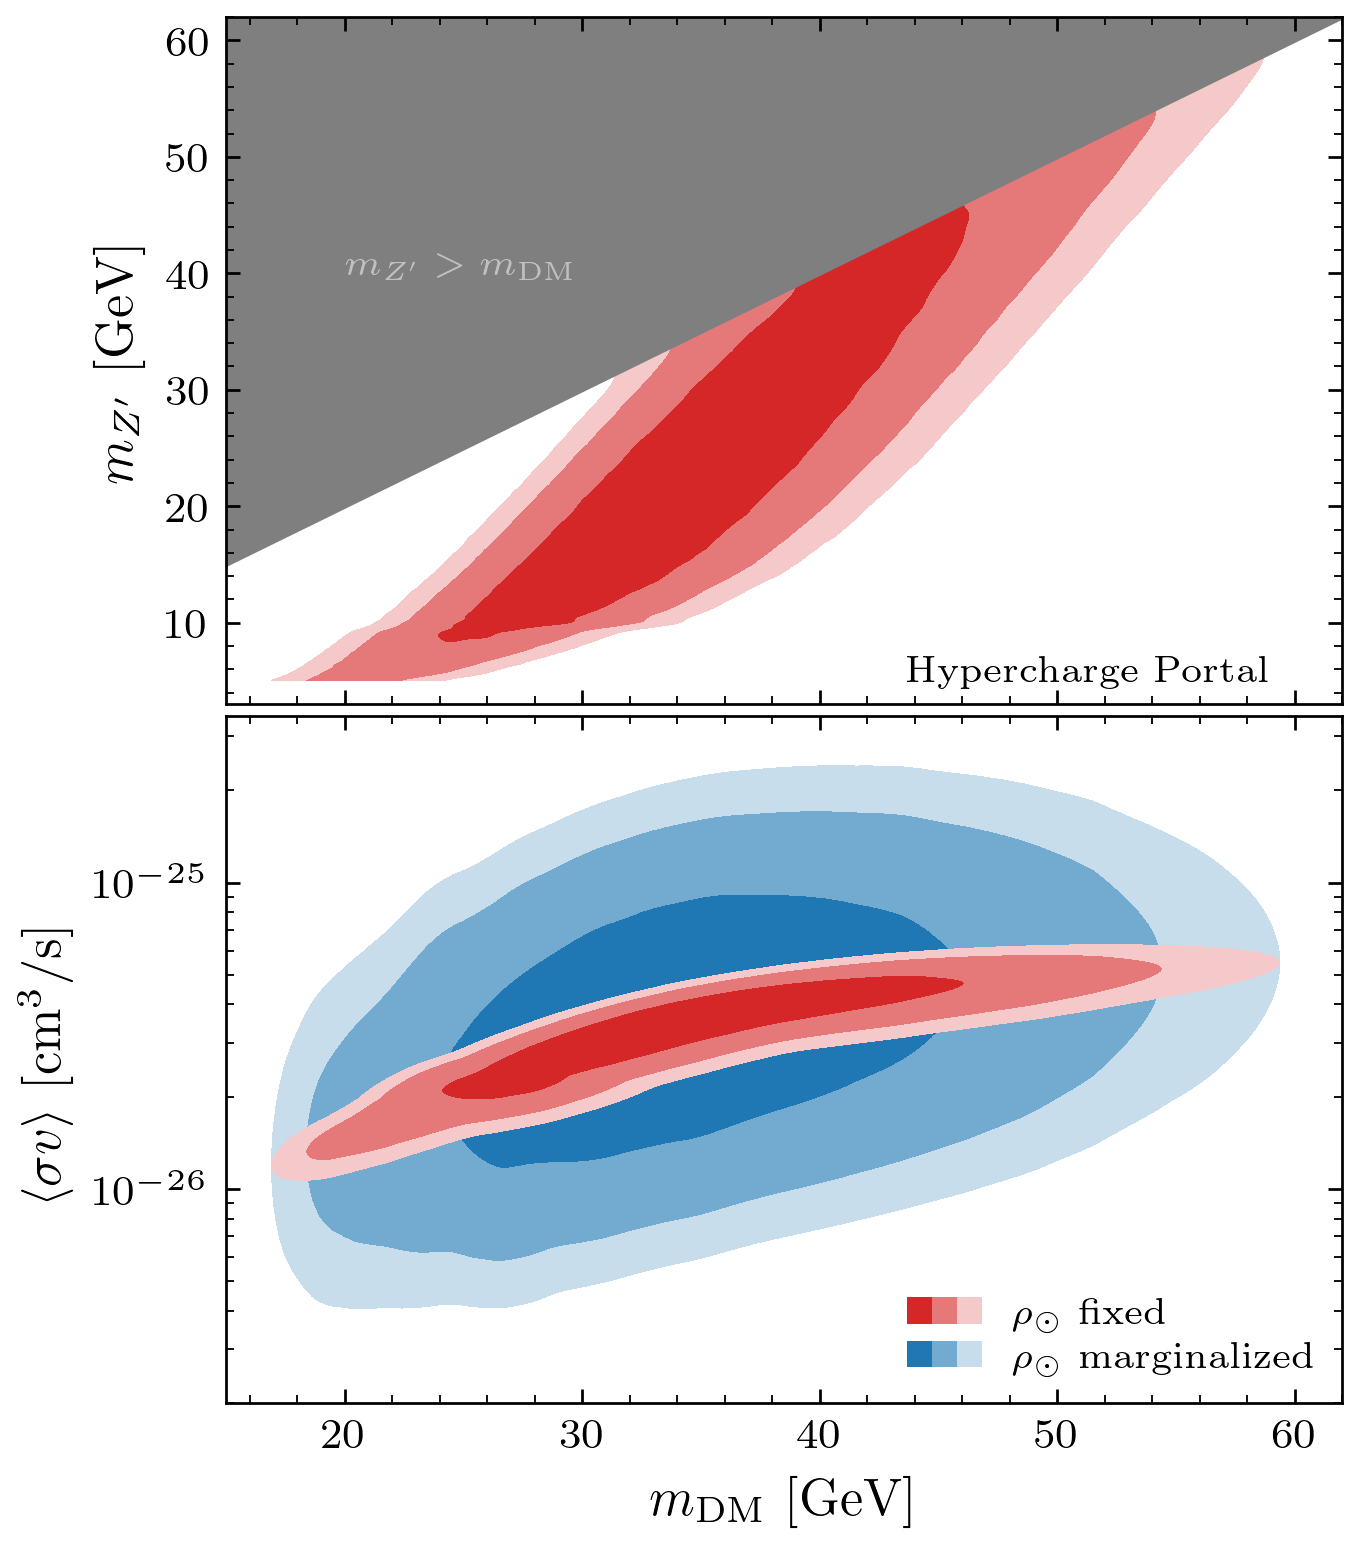

In [7]:
xi, yi, zs = smoothed_field(MX_GRID, MY_GRID, chi2 - chi2[k_best],sigma=2)
dchi2_fixed_halo_smooth   = gaussian_filter1d(dchi2_fixed_halo,   1, axis=1, mode="nearest")
dchi2_marginalised_smooth = gaussian_filter1d(dchi2_marginalised, 1, axis=1, mode="nearest")

label_names=[ r'$\rho_{\odot}$ fixed', r'$\rho_{\odot}$ marginalized']
fig = plt.figure(figsize=(4, 5))
cs2=color_shades('tab:blue', 3)
cs=color_shades('tab:red', 3)
css=[cs,cs2]
gs = GridSpec(20, 20, figure=fig)  # 7 rows and 7 columns for the triangle plot
ax1= fig.add_subplot(gs[:10, :])
ax2= fig.add_subplot(gs[10:, :])
ax2.set_xlim(15,62)
ax1.set_xlim(15,62)
ax1.set_ylim(3, 62)
mDMs=np.linspace(10,65,50)
ax1.fill_between(mDMs,mDMs,np.ones(len(mDMs))*1e4,zorder=2, color='tab:grey')
ax1.contourf(xi, yi,zs, levels=[0.0, 2.30, 6.18,9.12], colors=[cs[0], cs[1], cs[2]], alpha=1)
ax2.contourf(mx_columns, sigmav_axis, dchi2_marginalised_smooth, levels=[0,2.30, 6.18, 9.12],
           colors=[cs2[0], cs2[1],cs2[2]], alpha=1)
ax2.contourf(mx_columns, sigmav_axis, dchi2_fixed_halo_smooth, levels=[0,2.30, 6.18, 9.12],
           colors=[cs[0], cs[1],cs[2]], alpha=1)


ax2.set_xlabel(r"$m_{\rm DM}\,\,[{\rm GeV}]$")
ax1.set_ylabel(r"$m_{Z^\prime}\,\,[{\rm GeV}]$")
ax1.text(20,40,r"$m_{Z^\prime}>m_{\rm DM}$", color="silver",  fontsize=mpl.rcParams['legend.fontsize'], ha='left')
ax2.set_ylabel(r"$\langle \sigma v\rangle\,\,[{\rm cm}^3/{\rm s}]$")
ax2.set_yscale("log")
ax2.set_ylim(2e-27,3.5e-25)
ax1.text(59,5,r'Hypercharge Portal', fontsize=mpl.rcParams['legend.fontsize'], ha='right')
ax1.set_xticklabels([])

handles,labels=[],[]
for i in range(2):
    patch99 = Patch(facecolor=css[i][2])
    patch95 = Patch(facecolor=css[i][1])
    patch68 = Patch(facecolor=css[i][0])
    labels  += [label_names[i]]
    handles += [(patch68, patch95, patch99)]
ax2.legend(
    handles=handles,
    labels=labels,
    loc=4,
    fontsize=mpl.rcParams['legend.fontsize'],
    handler_map={tuple: mpl.legend_handler.HandlerTuple(ndivide=None, pad=0.0)},
    )
plt.savefig("../figs/GCE_fit_vP_v2.png")
#plt.savefig("../figs/GCE_fit_vP.pdf")
plt.show()
plt.close()

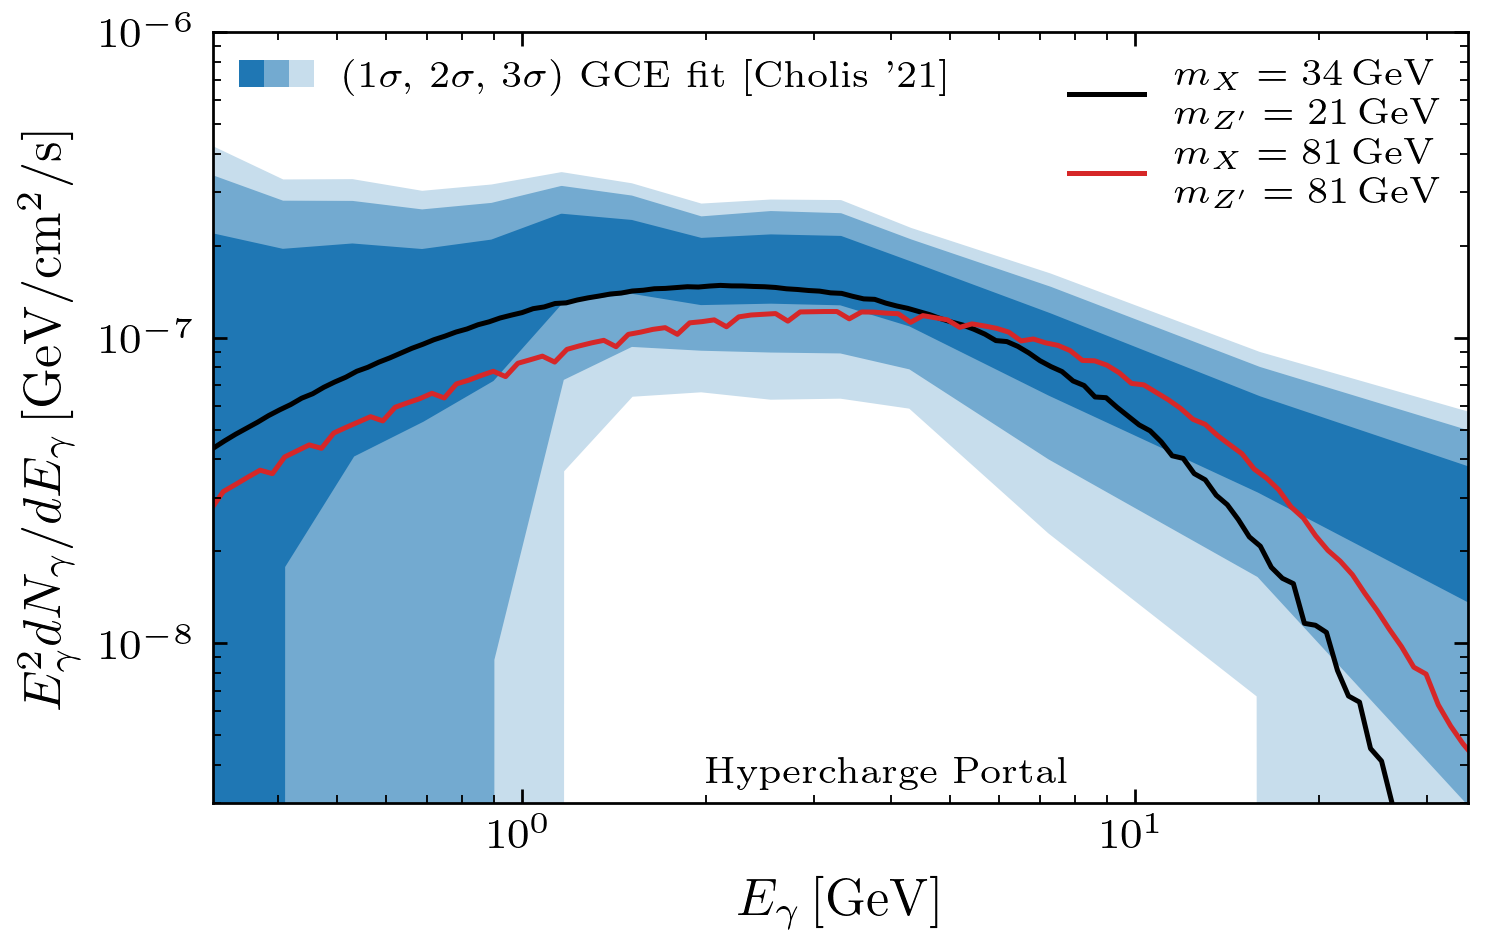

In [6]:
from GCE.gce_data import EBIN_CTR
from GCE.spectrum import cascade_flux, default_ebins, direct_flux
from GCE.halo import j_factor, HALO_2112
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.path import Path as MplPath

_, dOmega = j_factor(return_solid_angle=True, **{**HALO_2112, "roi": REGION})
k_bad=-2612
cs=color_shades('tab:blue', 3)
C = np.linalg.inv(Cinv)
draws = np.random.default_rng(0).multivariate_normal(phi, C, size=20000)
lo68, hi68 = np.percentile(draws, [16, 84], axis=0)
lo95, hi95 = np.percentile(draws, [2.5, 97.5], axis=0)
lo99, hi99 = np.percentile(draws, [0.5, 99.5], axis=0)
model_best = VectorPortal(mX=float(MX_GRID[k_best]), mY=float(MY_GRID[k_best]), gX=2, gY=3,
                             alphaX=ALPHAX)
flux_best=cascade_flux(model_best,default_ebins(model_best.mX, n_bins=180), sigmav=sigmav[k_best], n_events=N_EVENTS, seed=SEED)
model_bad = VectorPortal(mX=float(MX_GRID[k_bad]), mY=float(MY_GRID[k_bad]), gX=2, gY=3,
                             alphaX=ALPHAX)
flux_bad=cascade_flux(model_bad,default_ebins(model_bad.mX, n_bins=180), sigmav=sigmav[k_bad], n_events=N_EVENTS, seed=SEED)



plt.fill_between(EBIN_CTR, lo99*dOmega, hi99*dOmega, color=cs[2],alpha=1)
plt.fill_between(EBIN_CTR, lo95*dOmega, hi95*dOmega, color=cs[1],alpha=1)
plt.fill_between(EBIN_CTR, lo68*dOmega, hi68*dOmega, color=cs[0],alpha=1)
#plt.plot(EBIN_CTR,ts[k_best]*sigmav[k_best],c='k',lw=1)
#plt.plot(EBIN_CTR,ts[k_bad]*sigmav[k_bad],c='tab:blue',lw=1)
plt.plot(flux_best[0], flux_best[0]**2*flux_best[1]*dOmega, c='k', lw=1,
         label=rf'$m_X={MX_GRID[k_best]:.0f}\,\mathrm{{GeV}}$' + '\n'
               + rf'$m_{{Z^\prime}}={MY_GRID[k_best]:.0f}\,\mathrm{{GeV}}$')
plt.plot(flux_bad[0], flux_bad[0]**2*flux_bad[1]*dOmega, c='tab:red', lw=1,
         label=rf'$m_X={MX_GRID[k_bad]:.0f}\,\mathrm{{GeV}}$' + '\n'
               + rf'$m_{{Z^\prime}}={MY_GRID[k_bad]:.0f}\,\mathrm{{GeV}}$')
leg1 = plt.legend()
p99 = Patch(facecolor=cs[2])
p95 = Patch(facecolor=cs[1])
p68 = Patch(facecolor=cs[0])
leg2=plt.legend(
    handles=[(p68, p95, p99)],
    labels=["$(1\sigma,\,2\sigma,\,3\sigma)$ GCE fit [Cholis '21]"],
    loc=2,
    handler_map={tuple: mpl.legend_handler.HandlerTuple(ndivide=None, pad=0.0)},
    )
plt.gca().add_artist(leg1)
plt.yscale("log")
plt.xscale("log")
plt.ylim(3e-9,1e-6)
plt.xlim(EBIN_CTR[0],EBIN_CTR[-1])
plt.ylabel(r"$E^2_\gamma dN_\gamma/dE_\gamma\,[{\rm GeV}/{\rm cm}^2/{\rm s}]$")
plt.xlabel(r"$E_\gamma\,[{\rm GeV}]$")
plt.text(2,3.5e-9,r'Hypercharge Portal', fontsize=mpl.rcParams['legend.fontsize'], ha='left')
plt.savefig("../figs/GCE_spec_example_vP.png")
#plt.savefig("../figs/GCE_spec_example_vP.pdf")
plt.show()
plt.close()

In [8]:
# ---- alpha_X that gives Omega_c h^2 = 0.12 in the SM-thermalised regime ----


OCH2_TARGET  = 0.12
N_MX_COARSE  = 46            # coarse (log10 mX, log10 mY/mX) grid, interpolated onto GRID
N_RV_COARSE  = 34
RV_MAX       = 0.98          # XX -> YY shuts off at mY = mX
ALPHAX_RANGE = (1e-5, 1.0)   # perturbative ceiling alpha_X = gX^2 / 4pi < 1
RELIC_RTOL   = 3e-3

cosmo = Cosmology()

def _och2(mX, mY, alphaX):
    mdl = VectorPortal(mX=mX, mY=mY, gX=2, gY=3, alphaX=alphaX,
                       include_antiparticlesX=True, include_antiparticlesY=False)
    sol = BoltzmannSolver(cosmo, mdl).solve_boltzmann_thermSM(
        verbose=False, include_hidden_in_gstar=False)
    return sol['YX_relic'] * mX * s0_cosmo / rhoc

def _alphaX_relic(mX, mY):
    """alpha_X for Omega h^2 = OCH2_TARGET (nan if outside ALPHAX_RANGE);
    scaled guess + log-log secant, brentq fallback."""
    a_lo, a_hi = ALPHAX_RANGE
    a0 = 1e-2
    o0 = _och2(mX, mY, a0)
    a1 = float(np.clip(a0 * np.sqrt(o0 / OCH2_TARGET), a_lo, a_hi))
    o1 = _och2(mX, mY, a1)
    if abs(o1 / OCH2_TARGET - 1.0) < RELIC_RTOL:
        return a1
    la = (np.log(a1) + (np.log(OCH2_TARGET) - np.log(o1))
          * (np.log(a1) - np.log(a0)) / (np.log(o1) - np.log(o0)))
    a2 = float(np.clip(np.exp(la), a_lo, a_hi))
    if abs(_och2(mX, mY, a2) / OCH2_TARGET - 1.0) < RELIC_RTOL:
        return a2
    f = lambda l: np.log(_och2(mX, mY, np.exp(l)) / OCH2_TARGET)
    for lo, hi in ((a2 / 3.0, a2 * 3.0), (a_lo, a_hi)):
        try:
            return float(np.exp(brentq(f, np.log(max(lo, a_lo)),
                                       np.log(min(hi, a_hi)), rtol=1e-3)))
        except ValueError:
            continue
    return np.nan

# ---- solve on the coarse grid, interpolate log10 alpha_X onto GRID ----
lmx_c = np.linspace(np.log10(MX_GRID.min()), np.log10(MX_GRID.max()), N_MX_COARSE)
lrv_c = np.linspace(np.log10((MY_GRID / MX_GRID).min()), np.log10(RV_MAX), N_RV_COARSE)
LMX_C, LRV_C = np.meshgrid(lmx_c, lrv_c, indexing='ij')
"""
alphaX_c = np.full(LMX_C.shape, np.nan)
t0 = time.time()
for i in trange(N_MX_COARSE, desc='alphaX_relic'):
    for j in range(N_RV_COARSE):
        mX = 10.0 ** LMX_C[i, j]
        mY = mX * 10.0 ** LRV_C[i, j]
        if MY_LIM[0] <= mY <= RV_MAX * mX:
            alphaX_c[i, j] = _alphaX_relic(mX, mY)
"""
#np.save('../output/relic_grid_vP_thermal.npy',{'MXs':10**LMX_C, 'MYs':10**LRV_C*(10**LMX_C),'aXs_relic':alphaX_c})
Dict_vPtherm=np.load('../output/relic_grid_vP_thermal.npy', allow_pickle=True).item()
MX_C, MY_C,alphaX_c=Dict_vPtherm['MXs'], Dict_vPtherm['MYs'], Dict_vPtherm['aXs_relic']
LMX_C=np.log10(MX_C)
LRV_C=np.log10(MY_C/MX_C)
ok_c = np.isfinite(alphaX_c)


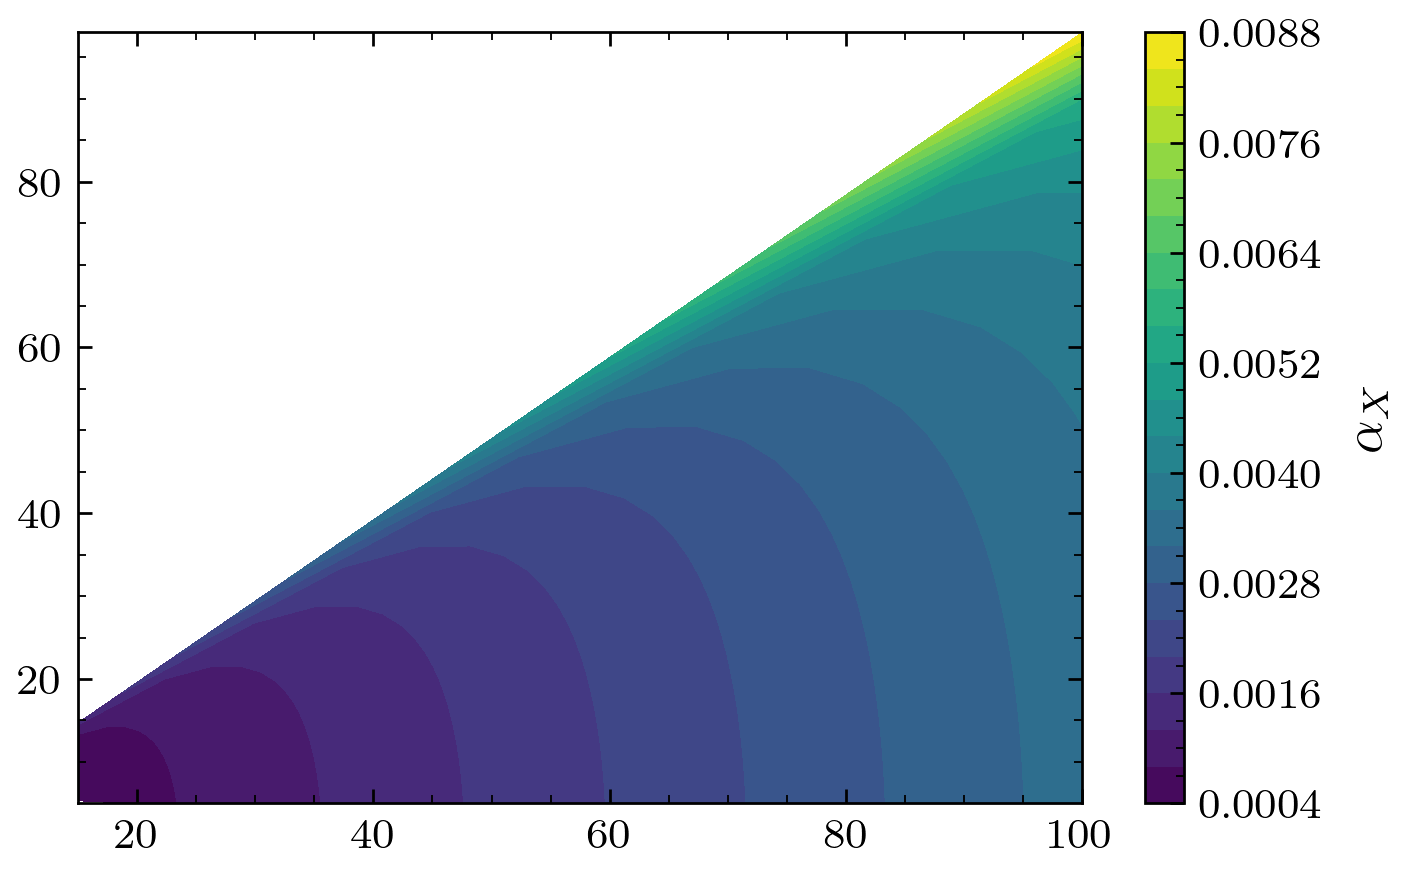

In [9]:
plt.tricontourf(10**(LMX_C[ok_c]), 10**(LRV_C[ok_c])*10**(LMX_C[ok_c]), alphaX_c[ok_c], levels=20, cmap='viridis')
plt.colorbar(label=r'$\alpha_X$')
plt.show()
plt.close()

alphaX_relic: 100%|█


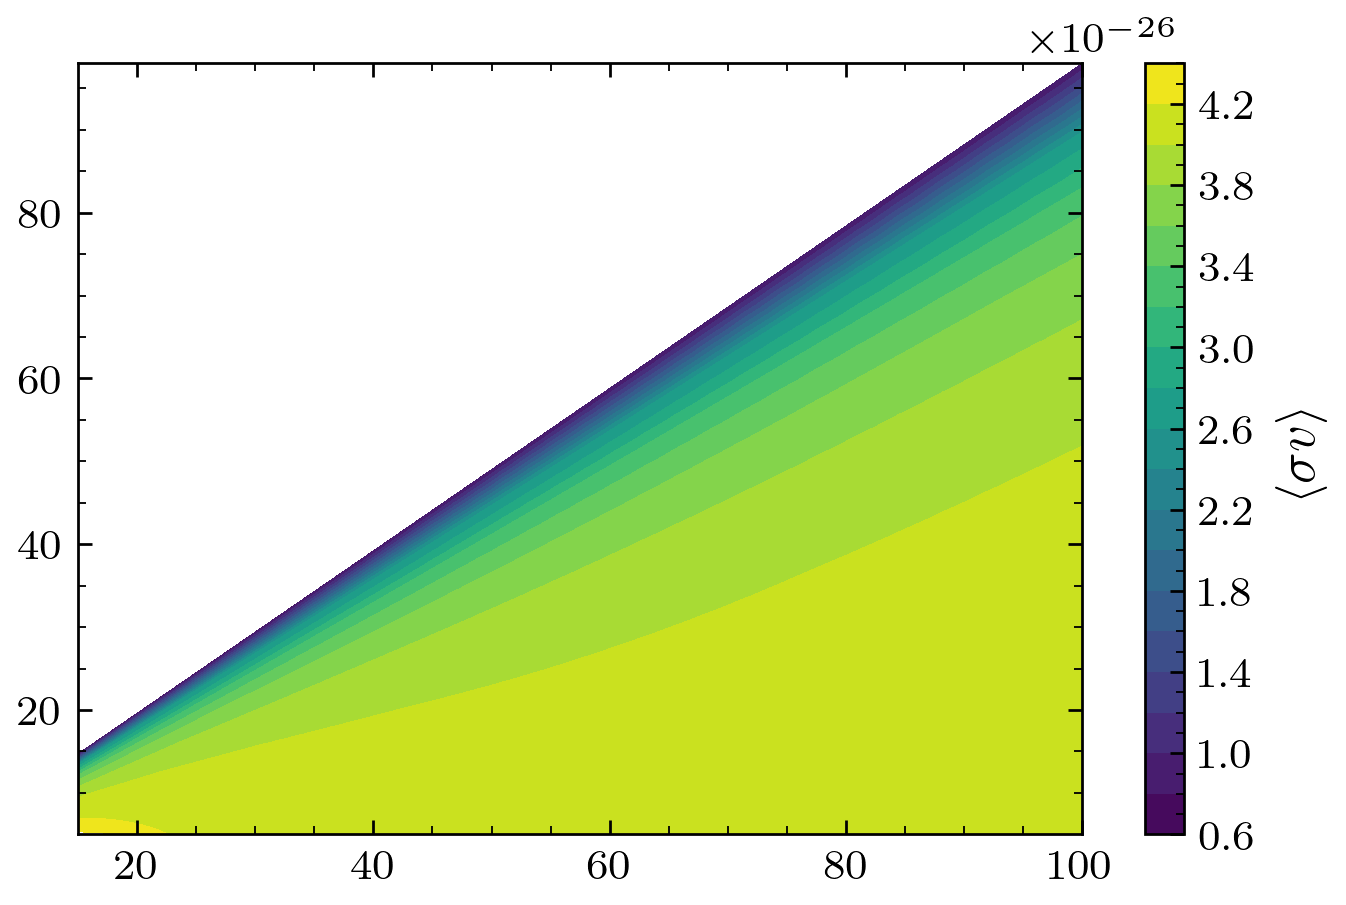

In [10]:
# ---- s-wave <sigma v> at that coupling, per grid point [cm^3/s] ----
sv_c =  np.full(LMX_C.shape, np.nan)
for i in trange(N_MX_COARSE, desc='alphaX_relic'):
    for j in range(N_RV_COARSE):
        mX_v = 10.0 ** LMX_C[i, j]
        mY_v = mX_v * 10.0 ** LRV_C[i, j]
        if not np.isnan(alphaX_c[i,j]):
            m = VectorPortal(mX=mX_v, mY=mY_v, gX=2, gY=3,
                     alphaX=float(alphaX_c[i,j]), include_antiparticlesX=True)
            sv_c[i,j] = m.sigmav_XX_to_YY_swave() * GEVM2_TO_CM3S
ok_sv=np.isfinite(sv_c)
plt.tricontourf(10**(LMX_C[ok_sv]), 10**(LRV_C[ok_sv])*10**(LMX_C[ok_sv]), sv_c[ok_sv]
                , levels=20, cmap='viridis')
plt.colorbar(label=r'$\langle \sigma v \rangle$')
plt.show()
plt.close()

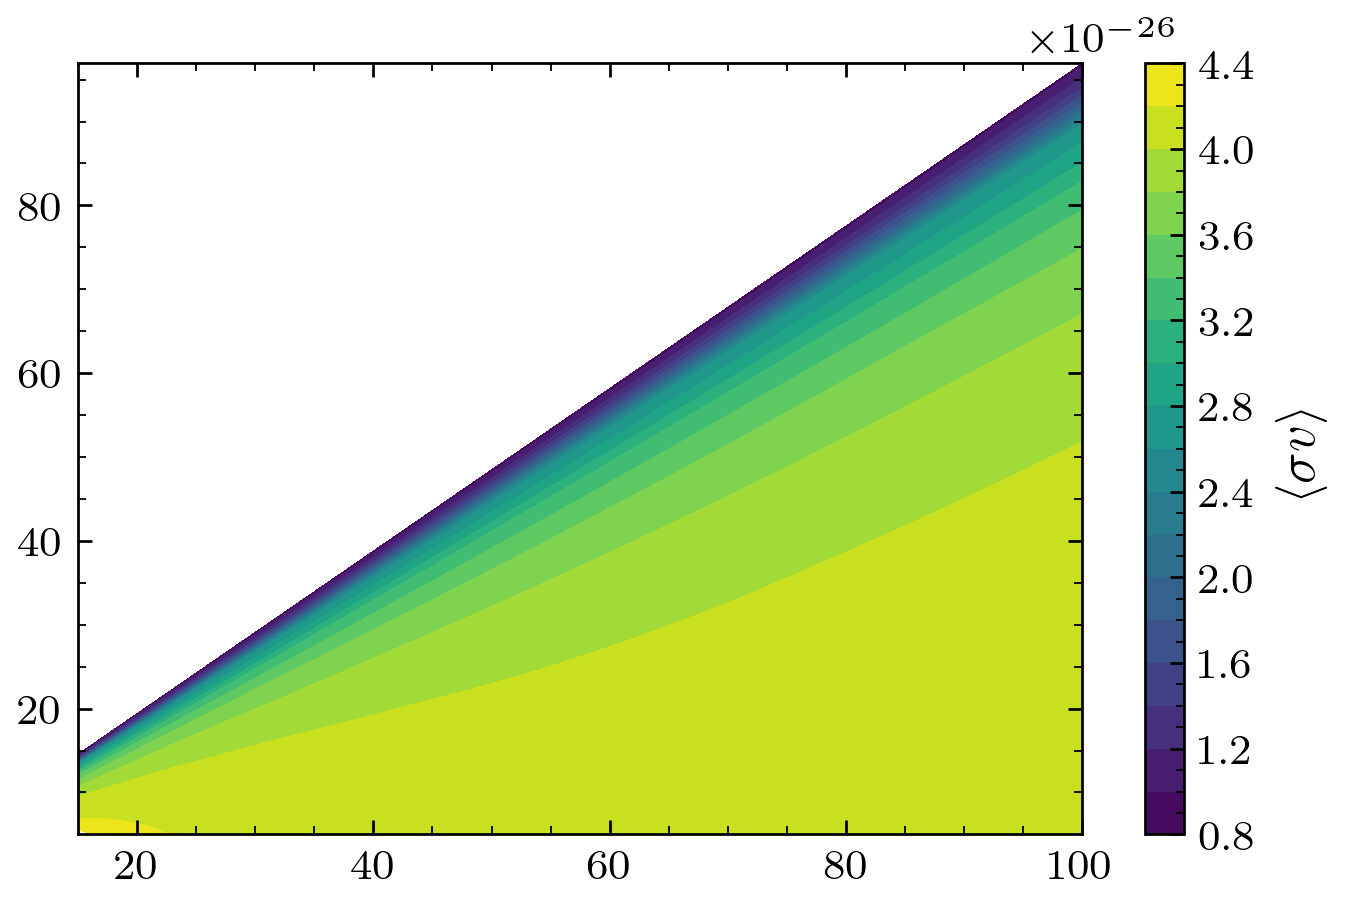

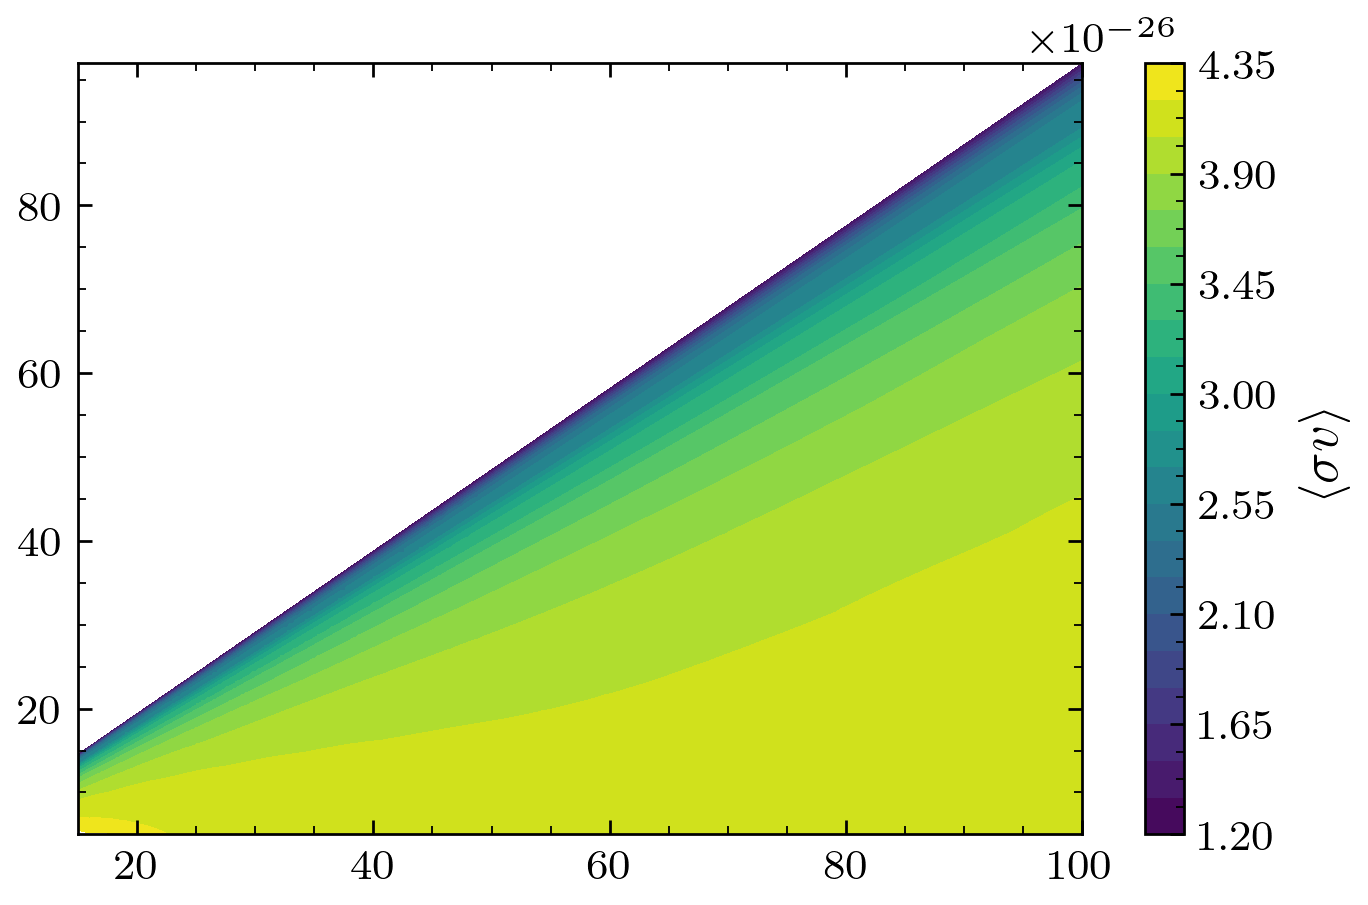

In [11]:
svX_relic = 10.0 ** griddata(
    np.column_stack([LMX_C[ok_c], LRV_C[ok_c]]), np.log10(sv_c[ok_c]),
    np.column_stack([np.log10(MX_GRID), np.log10(MY_GRID / MX_GRID)]), method='linear')
ok_cc=np.isfinite(svX_relic)
plt.tricontourf(MX_GRID[ok_cc],MY_GRID[ok_cc], svX_relic[ok_cc], levels=20, cmap='viridis')
plt.colorbar(label=r'$\langle \sigma v \rangle$')
plt.show()
alphaX_relic = 10.0 ** griddata(
    np.column_stack([LMX_C[ok_c], LRV_C[ok_c]]), np.log10(alphaX_c[ok_c]),
    np.column_stack([np.log10(MX_GRID), np.log10(MY_GRID / MX_GRID)]), method='linear')

# ---- s-wave <sigma v> at that coupling, per grid point [cm^3/s] ----
sv_relic = np.full(n_pts, np.nan)
for k in np.flatnonzero(np.isfinite(alphaX_relic)):
    m = VectorPortal(mX=float(MX_GRID[k]), mY=float(MY_GRID[k]), gX=2, gY=3,
                     alphaX=float(alphaX_relic[k]), include_antiparticlesX=True)
    sv_relic[k] = m.sigmav_XX_to_YY_swave() * GEVM2_TO_CM3S
sv_finite=np.isfinite(sv_relic)
plt.tricontourf(MX_GRID[sv_finite], MY_GRID[sv_finite], sv_relic[sv_finite], levels=20, cmap='viridis')
plt.colorbar(label=r'$\langle \sigma v \rangle$')
plt.show()


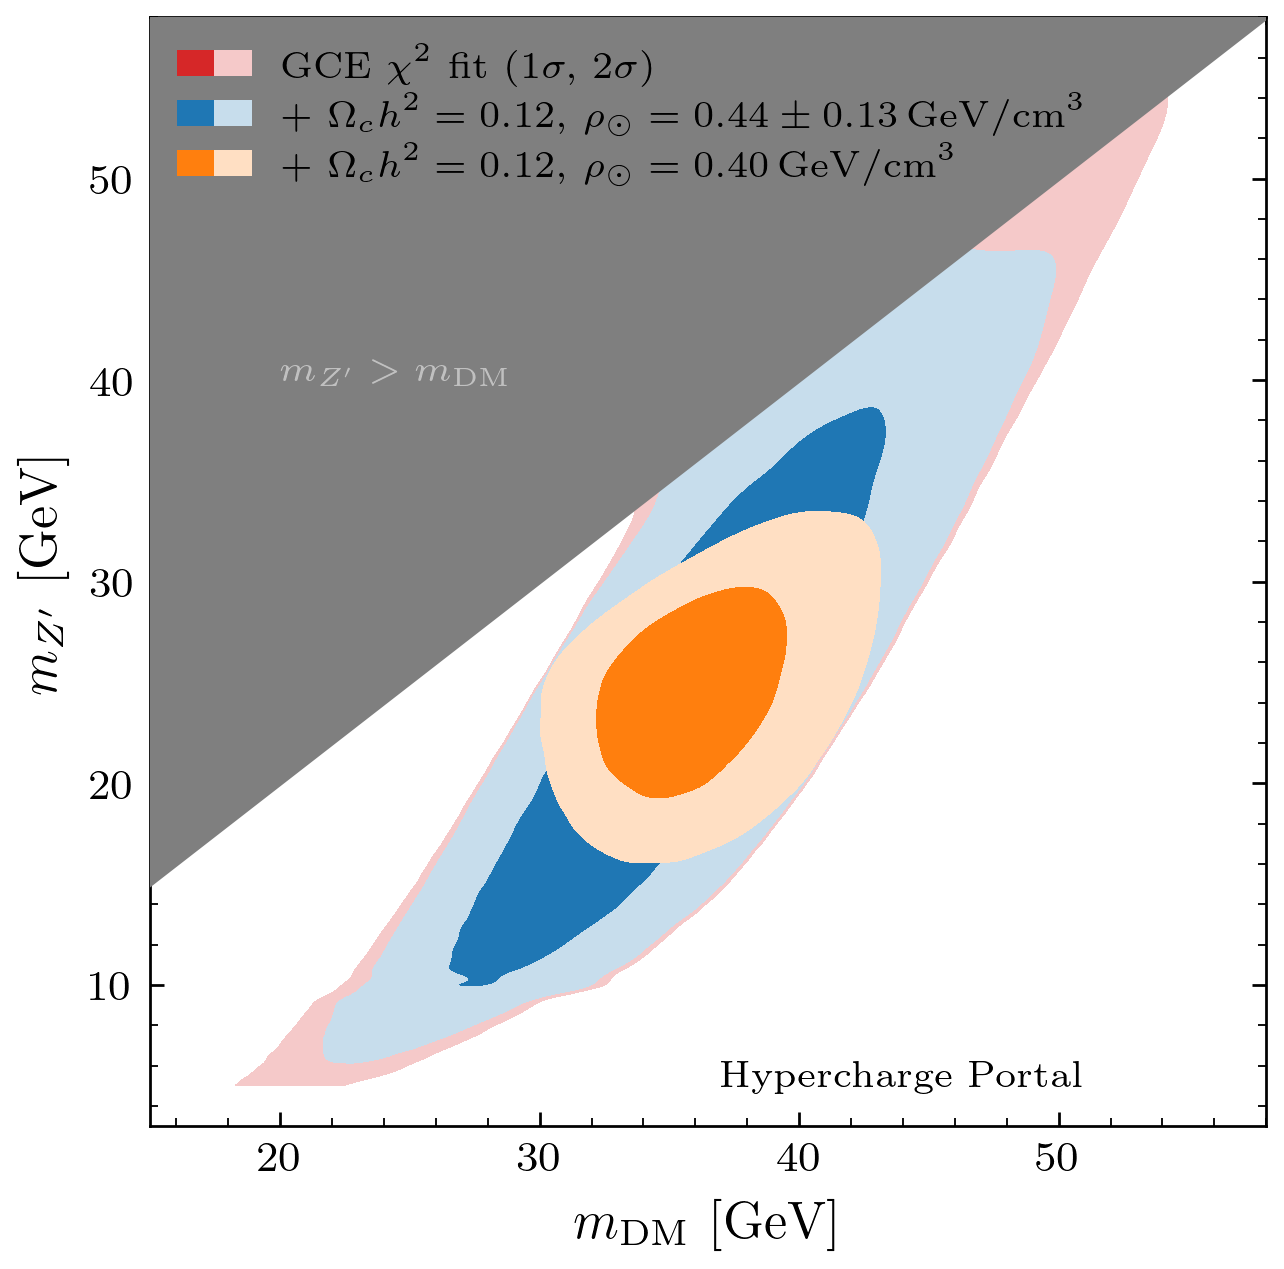

In [12]:
# ---- GCE region and the sub-region that also reproduces Omega_c h^2 = 0.12 ----
# dchi2_relic(mX,mY) = chi2(mX,mY, sv=sv_relic) - chi2_best.  sv_relic is a single
# value, so this is >= the sigma-v-profiled chi2 -> a subset of the GCE region.
fin = np.isfinite(sv_relic)
R = phi - sv_relic[fin, None] * ts[fin]
dchi2_relic = np.full(n_pts, np.nan)
dchi2_relic[fin] = np.einsum('ij,jk,ik->i', R, Cinv, R) - chi2[k_best]

xr, yr, zr = smoothed_field(MX_GRID[fin], MY_GRID[fin], dchi2_relic[fin], sigma=2.5, rezero=False)

# ---- same, with the local DM density marginalised (prior RHO_LOCAL_PRIOR) ----
# rho_sun is decoupled from freeze-out; it only rescales how the GCE sees the
# relic:  sv_eff = sv_relic * (rho_sun / 0.4)^2.  Profile it out with the prior.

rho_mean, rho_sigma = RHO_LOCAL_PRIOR
rho_w = rho_sigma / rho_mean
rho_samples = rho_mean * np.exp(np.linspace(-4, 4, 201) * rho_w)          # as cell 2
fac = (rho_samples / HALO_2112["rho_local"]) ** 2
pen = (np.log(rho_samples / rho_mean) / rho_w) ** 2

fin = np.isfinite(sv_relic)
rise = ((sv_relic[fin, None] * fac - sigmav[fin, None]) / sigmav_err[fin, None]) ** 2 + pen
dchi2_relic_marg = np.full(n_pts, np.nan)
dchi2_relic_marg[fin] = (chi2[fin] - chi2[k_best]) + rise.min(axis=1)

xr_marg, yr_marg, zr_marg = smoothed_field(MX_GRID[fin], MY_GRID[fin], dchi2_relic_marg[fin], sigma=2.5, rezero=False)

cs  = color_shades('tab:red', 2)
cs2 = color_shades('tab:blue', 2)
cs3 = color_shades('tab:orange', 2)
css=[cs,cs2,cs3]
fig, ax = plt.subplots(figsize=(4, 4))
mDMs = np.linspace(10, 60, 50)
ax.fill_between(mDMs, mDMs, np.ones(len(mDMs)) * 1e4, zorder=3, color='tab:grey')
ax.contourf(xi, yi, zs, levels=[0.0, 2.30, 6.18], colors=[cs[0], cs[1]])
#ax.contour(xi, yi, zs, levels=[2.30], colors=cs[0],zorder=2.5)
ax.contourf(xr_marg, yr_marg, zr_marg, levels=[0.0, 2.30, 6.18], colors=[cs2[0], cs2[1]], zorder=1.5)
ax.contourf(xr, yr, zr, levels=[0.0, 2.30, 6.18], colors=[cs3[0], cs3[1]], zorder=2)
ax.set_xlim(15, 58)
ax.set_ylim(3, 58)
ax.set_xlabel(r"$m_{\rm DM}\,\,[{\rm GeV}]$")
ax.set_ylabel(r"$m_{Z^\prime}\,\,[{\rm GeV}]$")
ax.text(20, 40, r"$m_{Z^\prime}>m_{\rm DM}$", color="silver",
        fontsize=mpl.rcParams['legend.fontsize'], ha='left')
ax.text(51, 5, r'Hypercharge Portal', fontsize=mpl.rcParams['legend.fontsize'], ha='right')

label_names=[ 'GCE $\chi^2$ fit ($1\sigma,\,2\sigma$)',
             r'$+\ \Omega_c h^2 = 0.12,\,\rho_{\odot}=0.44\pm 0.13\,{\rm GeV}/{\rm cm}^3$',
             r'$+\ \Omega_c h^2 = 0.12,\,\rho_{\odot}=0.40\,{\rm GeV}/{\rm cm}^3$',
            ]
handles,labels=[],[]
for i in range(3):
    patch95 = Patch(facecolor=css[i][1])
    patch68 = Patch(facecolor=css[i][0])
    labels  += [label_names[i]]
    handles += [(patch68, patch95)]
ax.legend(
    handles=handles,
    labels=labels,
    loc=2,
    fontsize=mpl.rcParams['legend.fontsize'],
    handler_map={tuple: mpl.legend_handler.HandlerTuple(ndivide=None, pad=0.0)},
    )
plt.savefig("../figs/GCE_fit_vP_relic.png")
#plt.savefig("../figs/GCE_fit_vP_relic.pdf")
plt.show()
plt.close()


In [13]:
EPS_JOINT    = (1e-9, 1e-10)
EPS_SECLUDED = (1e-11, 5e-12, 1e-12)
ALPHAX_LIM   = (2e-5, 1)
def get_sv_relic_at_eps(EPS_DISPLAY):
    # NOTE: np.isclose()'s default atol=1e-8 is larger than these eps values
    # themselves (1e-9 .. 1e-12), so it silently treated 1e-9, 1e-10 and 1e-11
    # as "the same" eps and always loaded the eps=1e-11 secluded slice for all
    # three -- exact equality is correct (and simpler) since EPS_DISPLAY is
    # always one of the fixed literals in EPS_JOINT / EPS_SECLUDED.
    if EPS_DISPLAY in EPS_SECLUDED:
        relic = np.load("../output/relic/relic_grid_vP_eps_secluded.npz")
        e_idx = int(np.flatnonzero(relic["eps"] == EPS_DISPLAY)[0])
        alphaX_c_eps = relic["alpha_relic"][e_idx]
    else:
        relic = np.load(f"../output/relic/relic_grid_vP_eps{EPS_DISPLAY:.0e}.npz")
        alphaX_c_eps = relic["alpha_relic"]
    LMX_C_eps, LRV_C_eps = np.meshgrid(relic["log_mX"], relic["log_rv"], indexing="ij")

    # keep only coarse nodes whose alpha_relic is an interpolated (not extrapolated)
    # read of the sampled Omega h^2(alpha_X) curve
    axis = relic["alphaX"]
    ok_c_eps = (np.isfinite(alphaX_c_eps)
                & (alphaX_c_eps >= axis.min()) & (alphaX_c_eps <= axis.max()))
    """
    if EPS_DISPLAY<=1e-9:
        plt.tricontourf(10**LMX_C_eps[ok_c_eps], 10**LMX_C_eps[ok_c_eps]*10**LRV_C_eps[ok_c_eps],np.log10(alphaX_c_eps[ok_c_eps]) , levels=20, cmap='viridis')
        plt.colorbar(label=r'$\alpha_X$')
        plt.show()
        plt.close()
    """
    alphaX_relic_eps = 10.0 ** griddata(
        np.column_stack([LMX_C_eps[ok_c_eps], LRV_C_eps[ok_c_eps]]),
        np.log10(alphaX_c_eps[ok_c_eps]),
        np.column_stack([np.log10(MX_GRID), np.log10(MY_GRID / MX_GRID)]), method="linear")
    sv_relic_eps = np.full(n_pts, np.nan)
    for k in np.flatnonzero(np.isfinite(alphaX_relic_eps)):
        m = VectorPortal(mX=float(MX_GRID[k]), mY=float(MY_GRID[k]), gX=2, gY=3,
                     alphaX=float(alphaX_relic_eps[k]), include_antiparticlesX=True)
        sv_relic_eps[k] = m.sigmav_XX_to_YY_swave() * GEVM2_TO_CM3S
    fin_eps = np.isfinite(sv_relic_eps)
    if EPS_DISPLAY<=1e-9:
        plt.tricontourf(MX_GRID[fin_eps], MY_GRID[fin_eps],np.log10(sv_relic_eps[fin_eps]) , levels=20, cmap='viridis')
        plt.colorbar(label=r'$\langle \sigma v \rangle$')
        plt.show()
        plt.close()
    R_eps = phi - sv_relic_eps[fin_eps, None] * ts[fin_eps]
    dchi2_relic_eps = np.full(n_pts, np.nan)
    dchi2_relic_eps[fin_eps] = np.einsum('ij,jk,ik->i', R_eps, Cinv, R_eps) - chi2[k_best]
    xe, ye, ze = smoothed_field(MX_GRID[fin_eps], MY_GRID[fin_eps], dchi2_relic_eps[fin_eps], sigma=2, rezero=False)
    # ---- same, with the local DM density marginalised (prior RHO_LOCAL_PRIOR) ----
    # as cells 7/8: sv_eff = sv_relic_eps * (rho_sun / 0.4)^2, rho_sun profiled out.
    rho_mean, rho_sigma = RHO_LOCAL_PRIOR
    rho_w = rho_sigma / rho_mean
    rho_samples = rho_mean * np.exp(np.linspace(-4, 4, 201) * rho_w)
    fac = (rho_samples / HALO_2112["rho_local"]) ** 2
    pen = (np.log(rho_samples / rho_mean) / rho_w) ** 2
    rise_eps = ((sv_relic_eps[fin_eps, None] * fac - sigmav[fin_eps, None]) / sigmav_err[fin_eps, None]) ** 2 + pen
    dchi2_relic_eps_marg = np.full(n_pts, np.nan)
    dchi2_relic_eps_marg[fin_eps] = (chi2[fin_eps] - chi2[k_best]) + rise_eps.min(axis=1)
    xe_marg, ye_marg, ze_marg = smoothed_field(MX_GRID[fin_eps], MY_GRID[fin_eps],
                                          dchi2_relic_eps_marg[fin_eps], sigma=2, rezero=False)
    return {'xe':xe,'ye':ye,'ze':ze,
            'xe_marg':xe_marg,'ye_marg':ye_marg,'ze_marg':ze_marg,
            'sv_relic_eps':sv_relic_eps}

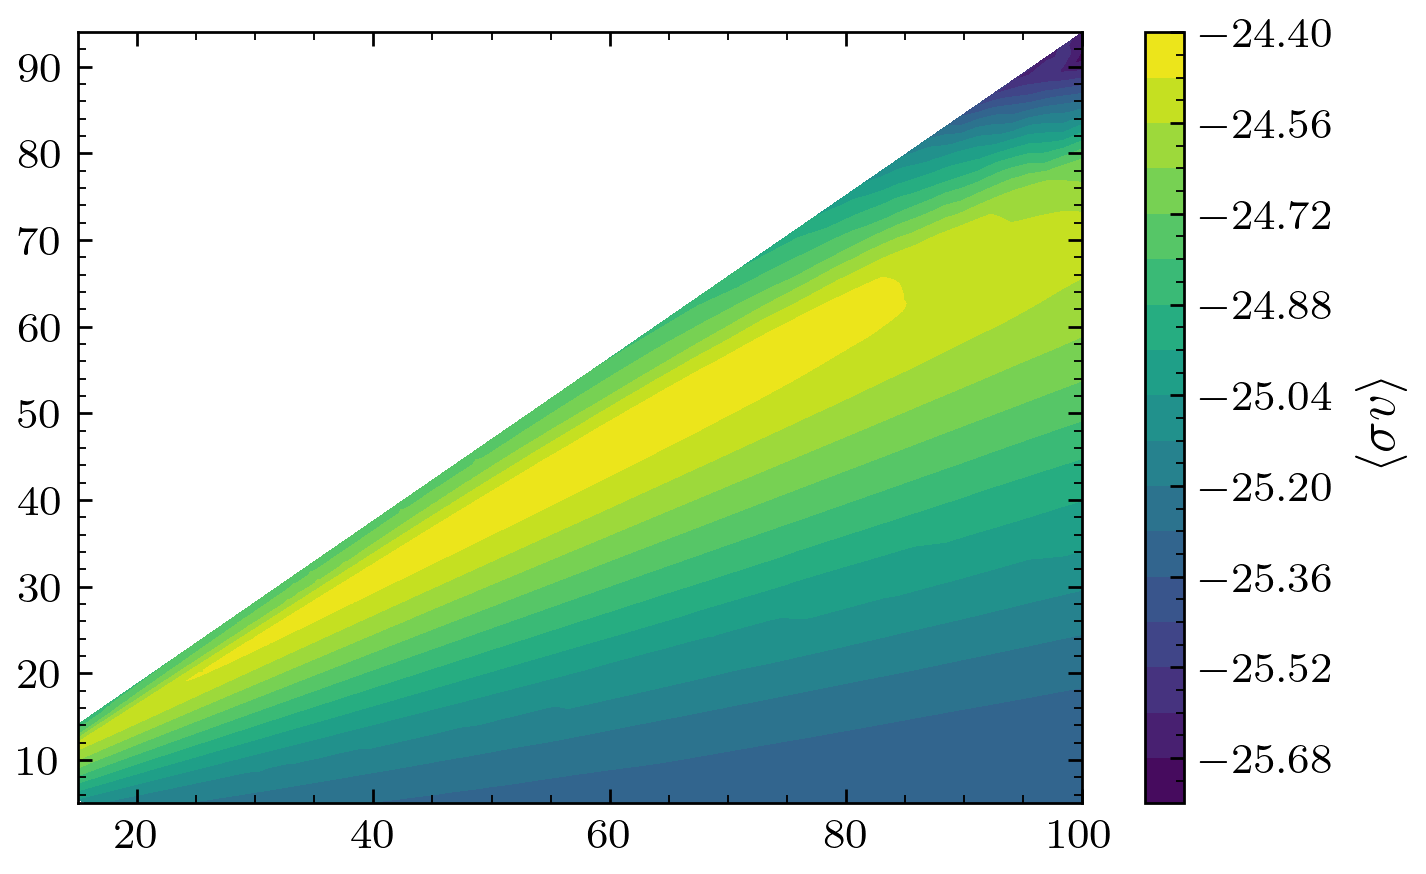

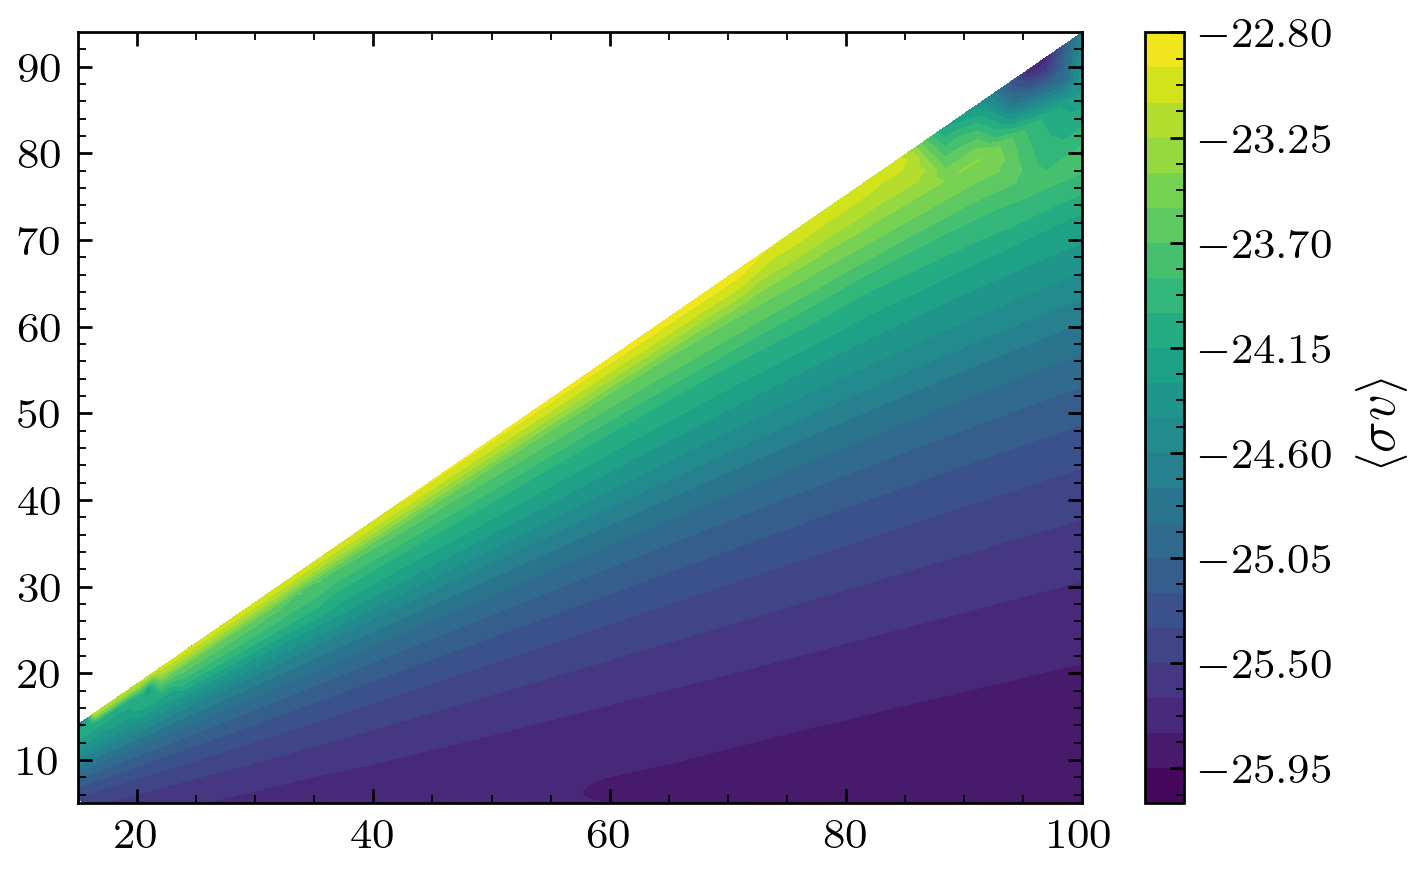

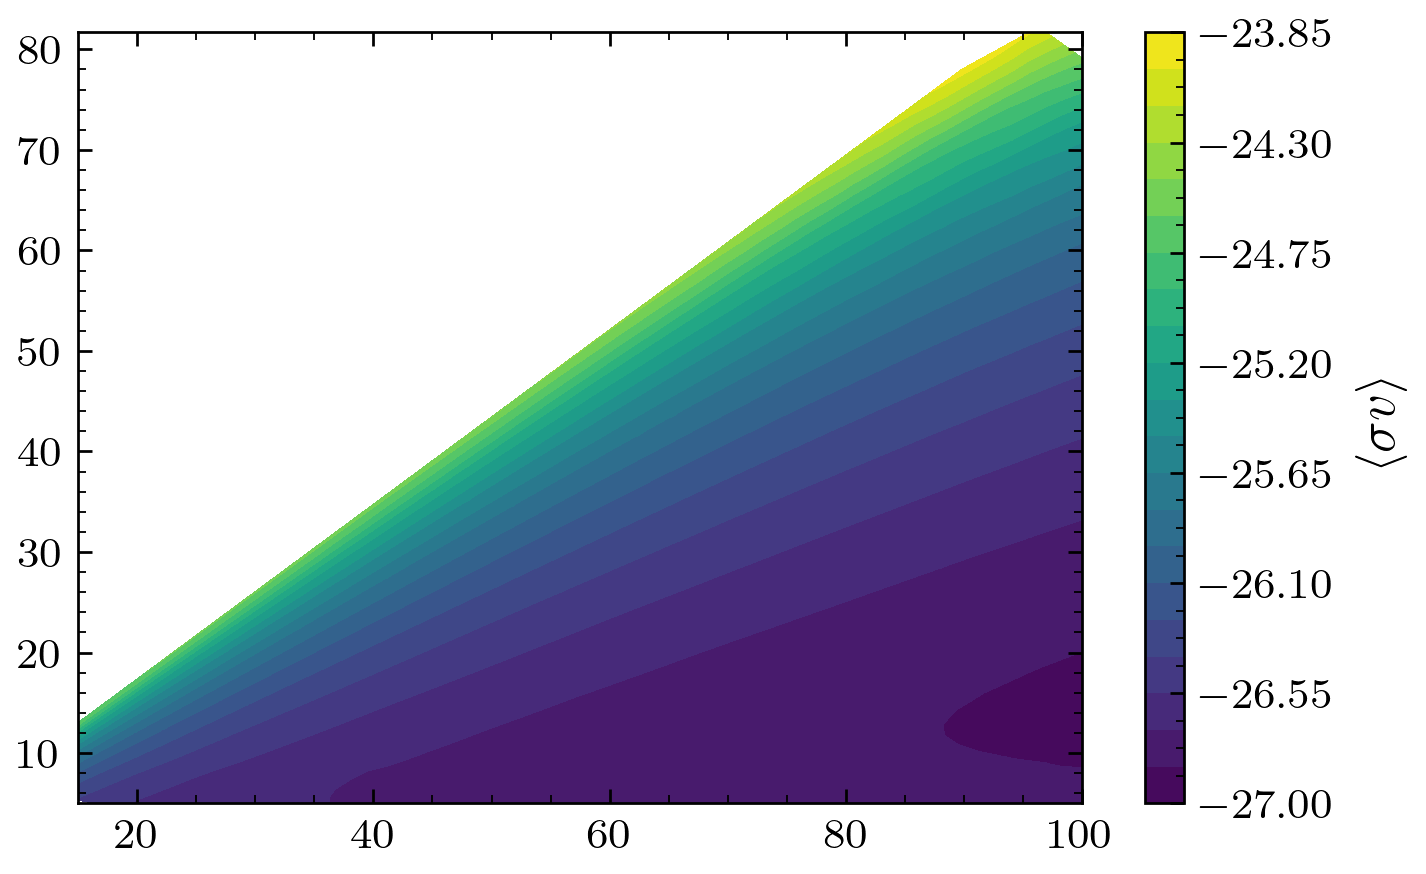

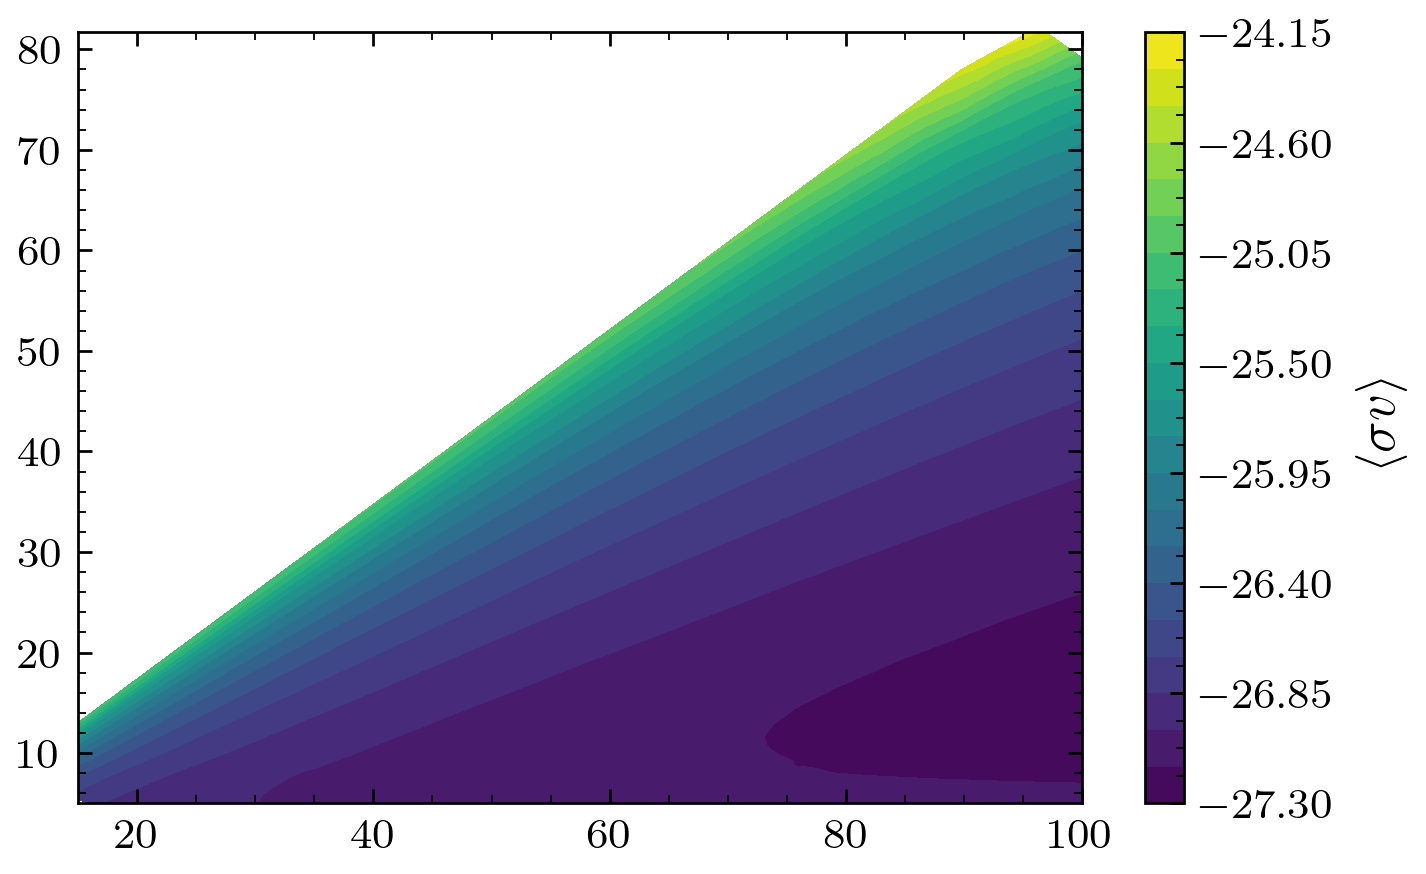

In [14]:
eps1_info=get_sv_relic_at_eps(1e-9)
eps2_info=get_sv_relic_at_eps(1e-10)
eps3_info=get_sv_relic_at_eps(1e-11)
eps4_info=get_sv_relic_at_eps(5e-12)
#eps5_info=get_sv_relic_at_eps(1e-12)

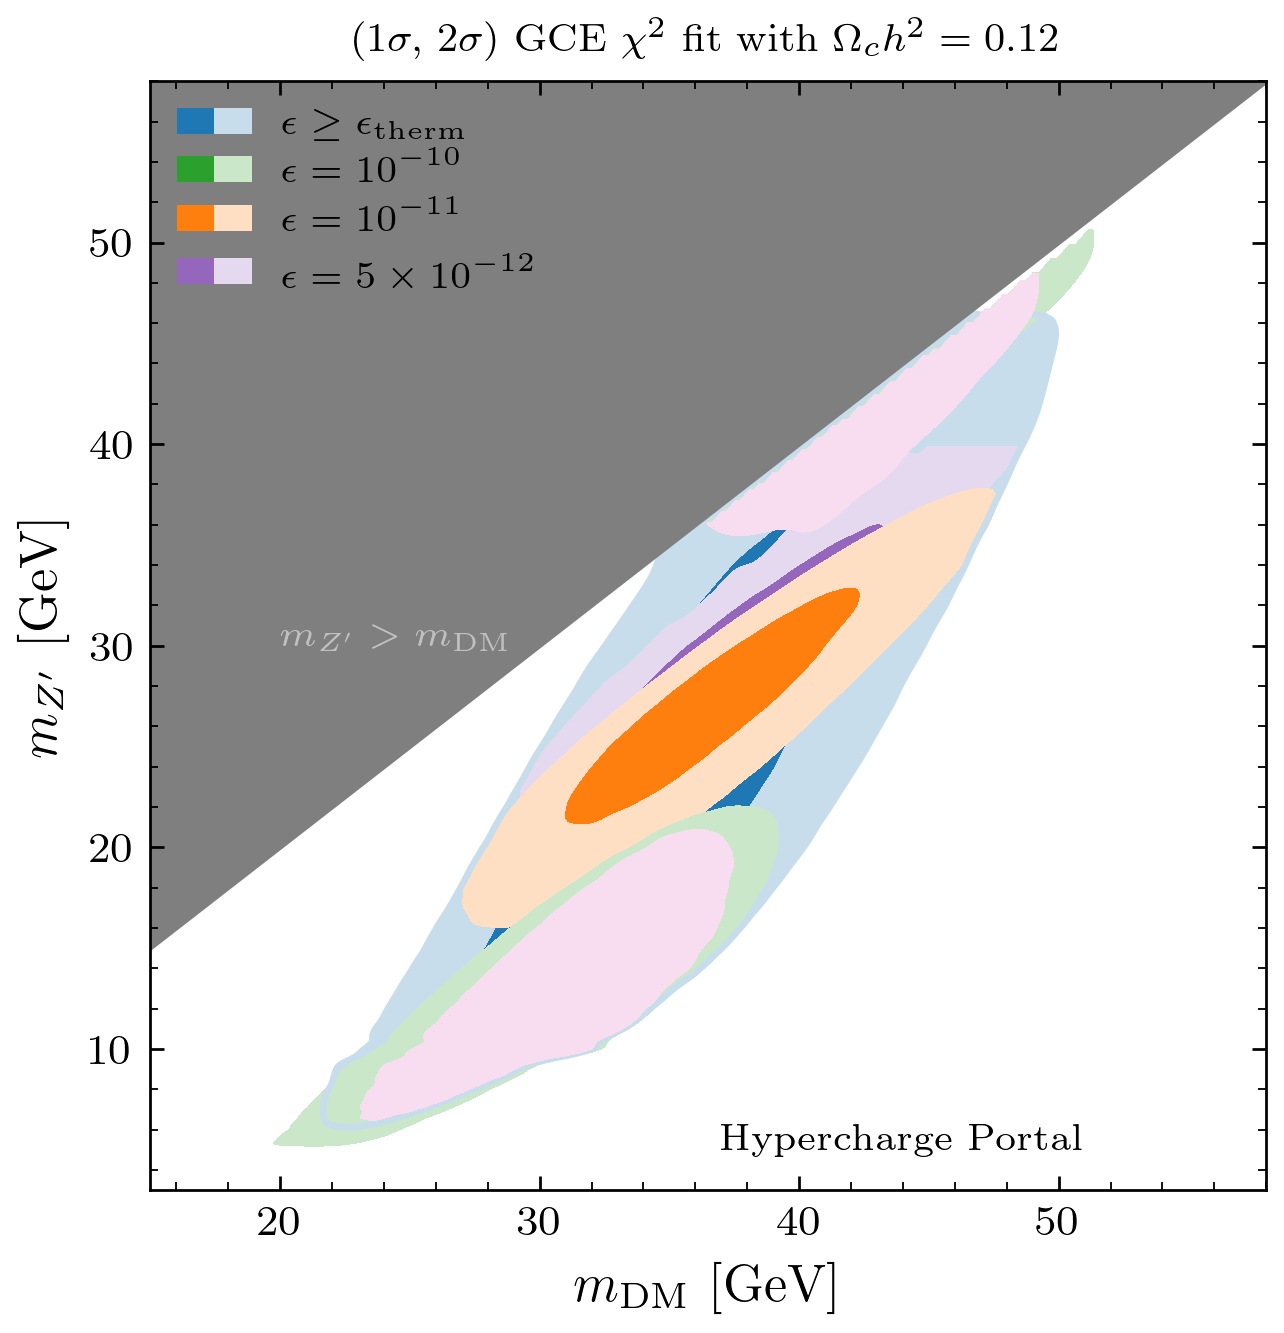

In [16]:
# ---- GCE region, thermalised relic subset, and the eps=EPS_DISPLAY (diluted)
# relic subset, fixed rho_odot and marginalised over RHO_LOCAL_PRIOR --
# starting benchmark, edit freely ----


cs = color_shades('tab:blue', 2)
cs2 = color_shades('tab:green', 2)
cs1 = color_shades('tab:pink', 2)
cs3 = color_shades('tab:orange', 2)
cs4 = color_shades('tab:purple', 2)
fig, ax = plt.subplots(figsize=(4, 4))
mDMs = np.linspace(10, 60, 50)
ax.fill_between(mDMs, mDMs, np.ones(len(mDMs)) * 1e4, zorder=2, color='tab:grey')
#ax.contourf(xi, yi, zs, levels=[0, 6.18], colors=cs[0])
ax.contourf(eps1_info['xe_marg'], eps1_info['ye_marg'], eps1_info['ze_marg'], levels=[0, 2.30,9.12], colors=[cs1[0],cs1[1]], zorder=3)
ax.contourf(xr_marg, yr_marg, zr_marg, levels=[0,2.30, 6.18], colors=[cs[0],cs[1]], zorder=1.5)
ax.contourf(eps2_info['xe_marg'], eps2_info['ye_marg'], eps2_info['ze_marg'], levels=[0,2.30, 6.18], colors=[cs2[0],cs2[1]], zorder=1.8)
ax.contourf(eps3_info['xe_marg'], eps3_info['ye_marg'], eps3_info['ze_marg'], levels=[0,2.30, 6.18], colors=[cs3[0],cs3[1]], zorder=1.7)
mask = np.ma.masked_where(eps4_info['ye_marg'] >= 40, eps4_info['ze_marg'])
ax.contourf(eps4_info['xe_marg'], eps4_info['ye_marg'], mask, levels=[0,2.30, 6.18], colors=[cs4[0],cs4[1]], zorder=1.65)
ax.contour(xr_marg, yr_marg, zr_marg, levels=[6.18], colors=cs[1], zorder=1.9)
ax.set_xlim(15, 58)
ax.set_ylim(3, 58)
ax.set_xlabel(r"$m_{\rm DM}\,\,[{\rm GeV}]$")
ax.set_ylabel(r"$m_{Z^\prime}\,\,[{\rm GeV}]$")
ax.text(20, 30, r"$m_{Z^\prime}>m_{\rm DM}$", color="silver",
        fontsize=mpl.rcParams['legend.fontsize'], ha='left',zorder=10)
ax.text(51, 5, r'Hypercharge Portal', fontsize=mpl.rcParams['legend.fontsize'], ha='right')
ax.set_title(r"$(1\sigma,\,2\sigma)$ GCE $\chi^2$ fit with $\Omega_c h^2 = 0.12$",fontsize=8)

label_names = [r'$\epsilon\geq \epsilon_{\rm therm}$',
              r'$\epsilon=10^{-10}$',
              r'$\epsilon=10^{-11}$',
              r'$\epsilon=5\times10^{-12}$']
handles = [(Patch(facecolor=c[0]),Patch(facecolor=c[1])) for c in (cs, cs2,cs3, cs4)]


ax.legend(handles=handles, labels=label_names, loc=2,
         fontsize=mpl.rcParams['legend.fontsize'],
          labelspacing=0.4,
         handler_map={tuple: mpl.legend_handler.HandlerTuple(ndivide=None, pad=0.0)})
plt.savefig("../figs/GCE_fit_vP_relic_diluted.png")
plt.show()
plt.close()


100%|█| 4/4 [00:00<0


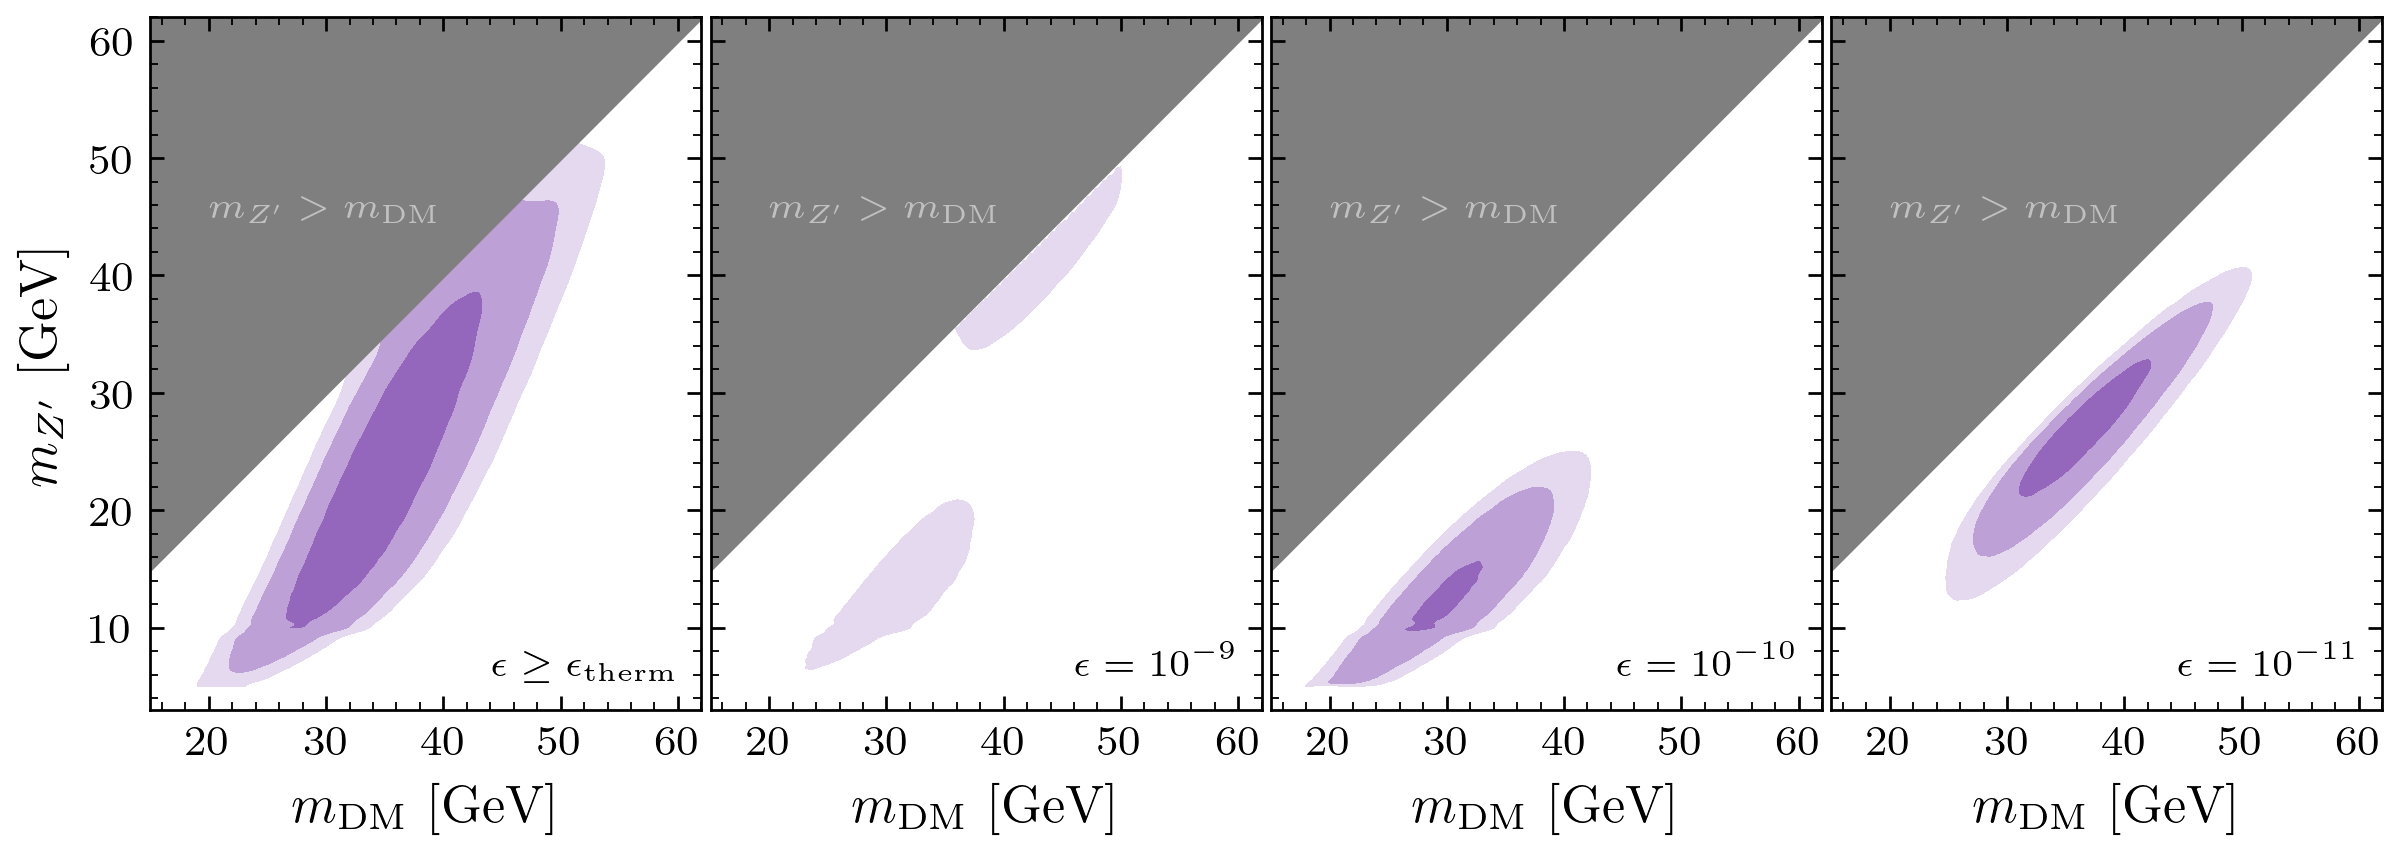

In [15]:
# ---- GCE region, thermalised relic subset, and the eps=EPS_DISPLAY (diluted)
# relic subset, fixed rho_odot and marginalised over RHO_LOCAL_PRIOR --
# starting benchmark, edit freely ----

epss_info=[eps1_info,eps2_info,eps3_info]
cs = color_shades('tab:purple', 3)
eps_tex= [r'$\epsilon\geq \epsilon_{\rm therm}$',
          r'$\epsilon=10^{-9}$',
          r'$\epsilon=10^{-10}$',
          r'$\epsilon=10^{-11}$'
         ]
fig= plt.figure(figsize=(8, 2.5))
mDMs = np.linspace(10, 70, 50)
gs = GridSpec(40, 40, figure=fig)  # 7 rows and 7 columns for the triangle plot
ax1= fig.add_subplot(gs[:, :10])
ax2= fig.add_subplot(gs[:,10:20])
ax3= fig.add_subplot(gs[:,20:30])
ax4= fig.add_subplot(gs[:,30:])
axs=[ax1,ax2,ax3,ax4]
for i in trange(len(axs)):
    axs[i].set_xlim(15,62)
    axs[i].set_xticks([20,30,40,50,60])
    axs[i].set_ylim(3, 62)
    axs[i].set_yticks([10,20,30,40,50,60])
    if i!=0:
        axs[i].set_yticklabels([])
        axs[i].contourf(epss_info[i-1]['xe_marg'], epss_info[i-1]['ye_marg'], epss_info[i-1]['ze_marg'], levels=[0, 2.30,6.18,9.12], colors=[cs[0],cs[1],cs[2]], zorder=3)
    axs[i].fill_between(mDMs,mDMs,np.ones(len(mDMs))*1e4,zorder=2, color='tab:grey')
    axs[i].text(20, 45, r"$m_{Z^\prime}>m_{\rm DM}$", color="silver",
        fontsize=mpl.rcParams['legend.fontsize'], ha='left',zorder=10)
    axs[i].text(60,6,eps_tex[i], fontsize=mpl.rcParams['legend.fontsize'], ha='right')
    axs[i].set_xlabel(r"$m_{\rm DM}\,\,[{\rm GeV}]$")
ax1.set_ylabel(r"$m_{Z^\prime}\,\,[{\rm GeV}]$")
#ax.contourf(eps1_info['xe_marg'], eps1_info['ye_marg'], eps1_info['ze_marg'], levels=[0, 2.30,9.12], colors=[cs1[0],cs1[1]], zorder=3)
ax1.contourf(xr_marg, yr_marg, zr_marg, levels=[0,2.30, 6.18,9.12], colors=[cs[0],cs[1],cs[2]], zorder=1.5)
"""
ax.fill_between(mDMs, mDMs, np.ones(len(mDMs)) * 1e4, zorder=2, color='tab:grey')
#ax.contourf(xi, yi, zs, levels=[0, 6.18], colors=cs[0])
ax.contourf(eps1_info['xe_marg'], eps1_info['ye_marg'], eps1_info['ze_marg'], levels=[0, 2.30,9.12], colors=[cs1[0],cs1[1]], zorder=3)
ax.contourf(xr_marg, yr_marg, zr_marg, levels=[0,2.30, 6.18], colors=[cs[0],cs[1]], zorder=1.5)
ax.contourf(eps2_info['xe_marg'], eps2_info['ye_marg'], eps2_info['ze_marg'], levels=[0,2.30, 6.18], colors=[cs2[0],cs2[1]], zorder=1.8)
ax.contourf(eps3_info['xe_marg'], eps3_info['ye_marg'], eps3_info['ze_marg'], levels=[0,2.30, 6.18], colors=[cs3[0],cs3[1]], zorder=1.7)
mask = np.ma.masked_where(eps4_info['ye_marg'] >= 40, eps4_info['ze_marg'])
ax.contourf(eps4_info['xe_marg'], eps4_info['ye_marg'], mask, levels=[0,2.30, 6.18], colors=[cs4[0],cs4[1]], zorder=1.65)
ax.contour(xr_marg, yr_marg, zr_marg, levels=[6.18], colors=cs[1], zorder=1.9)
ax.set_xlim(15, 58)
ax.set_ylim(3, 58)
ax.set_xlabel(r"$m_{\rm DM}\,\,[{\rm GeV}]$")
ax.set_ylabel(r"$m_{Z^\prime}\,\,[{\rm GeV}]$")
ax.text(20, 30, r"$m_{Z^\prime}>m_{\rm DM}$", color="silver",
        fontsize=mpl.rcParams['legend.fontsize'], ha='left',zorder=10)
ax.text(51, 5, r'Hypercharge Portal', fontsize=mpl.rcParams['legend.fontsize'], ha='right')
ax.set_title(r"$(1\sigma,\,2\sigma)$ GCE $\chi^2$ fit with $\Omega_c h^2 = 0.12$",fontsize=8)

label_names = [r'$\epsilon\geq \epsilon_{\rm therm}$',
              r'$\epsilon=10^{-10}$',
              r'$\epsilon=10^{-11}$',
              r'$\epsilon=5\times10^{-12}$']
handles = [(Patch(facecolor=c[0]),Patch(facecolor=c[1])) for c in (cs, cs2,cs3, cs4)]


ax.legend(handles=handles, labels=label_names, loc=2,
         fontsize=mpl.rcParams['legend.fontsize'],
          labelspacing=0.4,
         handler_map={tuple: mpl.legend_handler.HandlerTuple(ndivide=None, pad=0.0)})
plt.savefig("../figs/GCE_fit_vP_relic_diluted.png")
"""
plt.show()
plt.close()

No handles with labels found to put in legend.


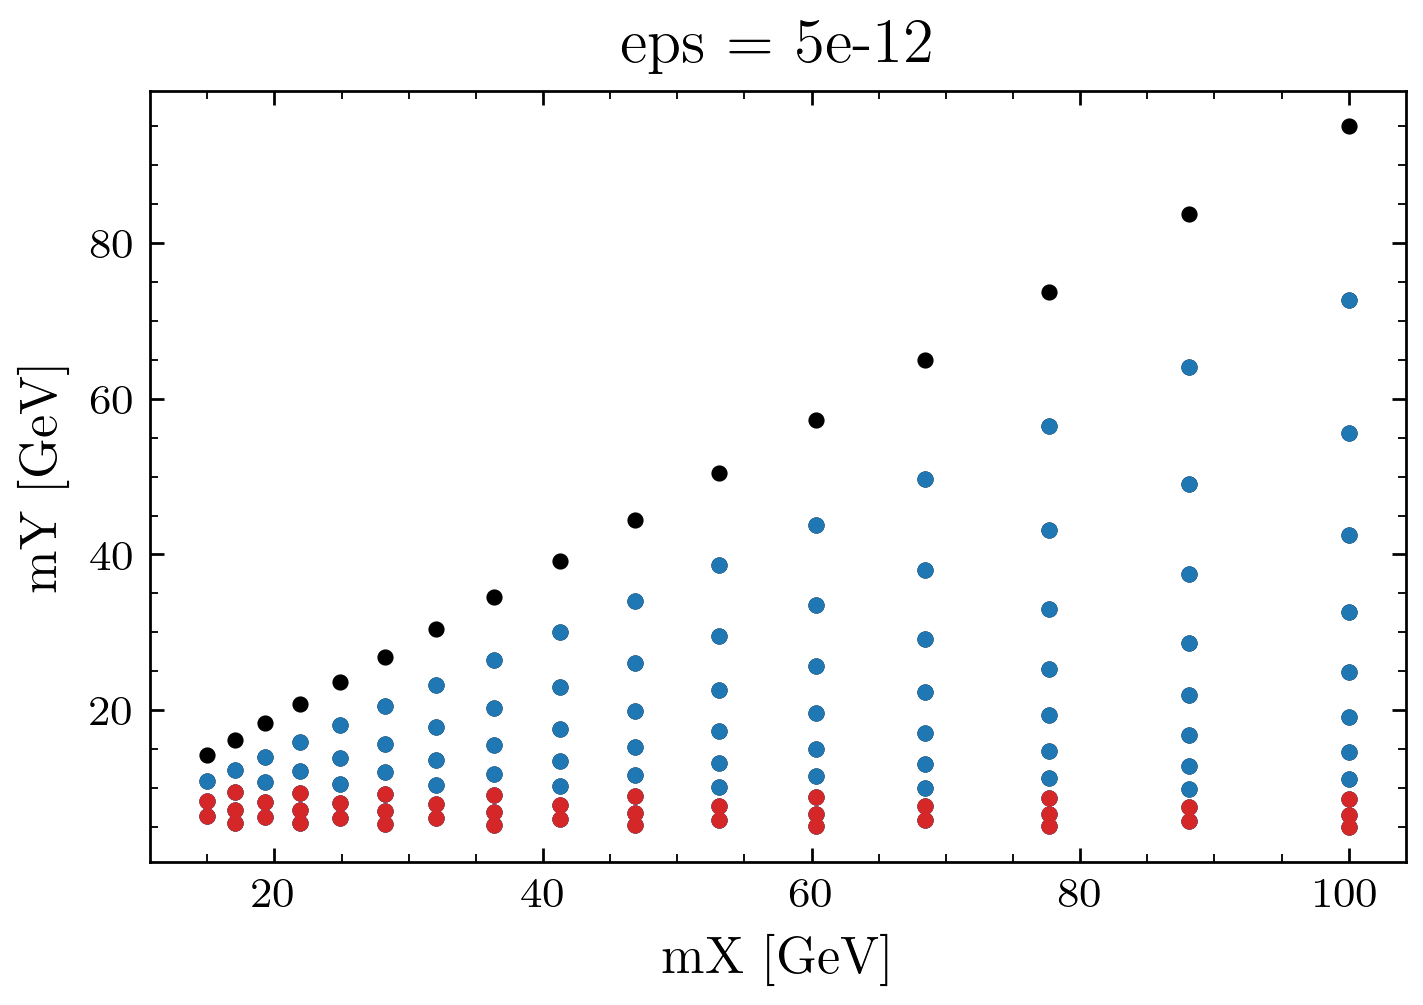

In [20]:
import numpy as np
import matplotlib.pyplot as plt

d = np.load("../output/relic/bbn_grid_vP.npz")   # "../output/relic/..." if run from GCE/notebooks/
mX_grid, mY_grid, eps, eps_bbn_min = d["mX_grid"], d["mY_grid"], d["eps"], d["eps_bbn_min"]

EPS_TARGET = 5e-12
e_idx = int(np.flatnonzero(eps == EPS_TARGET)[0])
excluded = eps_bbn_min[e_idx] > EPS_TARGET
ok_idx=np.isfinite(eps_bbn_min)[0]

plt.scatter(mX_grid, mY_grid, c="k",s=5)
plt.scatter(mX_grid[ok_idx], mY_grid[ok_idx], c="tab:blue",s=5)
plt.scatter(mX_grid[excluded], mY_grid[excluded], c="tab:red",s=5,zorder=2)
plt.xlabel("mX [GeV]")
plt.ylabel("mY [GeV]")
plt.title(f"eps = {EPS_TARGET:.0e}")
plt.legend()
plt.show()